In [1]:
import os
import pandas as pd
import numpy as np
import boto3
from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
# Suppress PerformanceWarning
warnings.filterwarnings('ignore')
import sklearn.metrics as skm
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn.metrics as skm
from scipy.stats import pearsonr
import datetime as dt

try:
    import catboost as cb
except:
    ! pip install catboost

In [2]:
print(f'Latest run date: {dt.datetime.now()}')

Latest run date: 2024-03-25 15:38:15.541734


### Functions

In [3]:
# download from s3
def download_from_s3(str_local_path, str_bucket_path, str_project):
    # download file
    boto3.client('s3').download_file(str_project, str_bucket_path, str_local_path)

### Constants

In [4]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')
str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')
str_dirname_output = './output'
str_variant = 'noPTImodel7'
flt_constant = 0.4324 # from best constant in previous notebook

Project: 20231010-gen-xii
Task: ad_hoc


### Output directory

In [5]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Load LGD data

In [6]:
list_str_df = [
    'train',
    'valid',
    'test',
]
list_df = []
for str_df in tqdm(list_str_df):
    str_filename = f'df_{str_df}_noleaks_pre.gzip'
    str_uri = f's3://{str_project}/03_pricing_lgd/02_model/{str_variant}/00_preprocessing/02_make_dfs/{str_filename}'
    df = pd.read_parquet(str_uri)
    df['data_set'] = str_df
    list_df.append(df)
df = pd.concat(list_df)
# this is where you will subset to ...
df

100%|██████████| 3/3 [00:02<00:00,  1.22it/s]


,linkf189__tu,linkf060__tu,linkf045__tu,linkb012__tu,intservicecontractmileage__app,intservicecontractterm__app,linkf185__tu,linkf105__tu,linkf193__tu,linkf195__tu,...,data_set,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age,target
8202,40.0,0.0,0.0,0.0,0.0,24.0,152.0,40.0,40.0,1141.0,...,train,2013,1.256262,10,4,0.09,1.370370,4.0,1.284932,-0.097929
8203,40.0,0.0,0.0,0.0,0.0,24.0,152.0,40.0,40.0,1141.0,...,train,2013,1.256262,10,4,0.09,1.370370,4.0,1.284932,-0.097929
8204,0.0,0.0,0.0,0.0,100000.0,48.0,0.0,0.0,0.0,0.0,...,train,2013,1.256262,10,4,0.15,1.586207,2.0,1.569863,0.464463
8205,0.0,0.0,0.0,0.0,100000.0,48.0,0.0,0.0,0.0,0.0,...,train,2013,1.256262,10,4,0.15,1.586207,2.0,1.569863,0.464463
8206,769.0,0.0,0.0,0.0,120000.0,0.0,5.0,5.0,5.0,1802.0,...,train,2013,1.256262,10,4,0.03,1.342857,1.0,3.961644,0.543609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,1540.0,0.0,0.0,0.0,120000.0,0.0,658.0,658.0,658.0,1601.0,...,test,2019,1.144717,10,4,0.09,1.236842,1.0,2.953425,0.175335
2335,48.0,0.0,0.0,0.0,120000.0,0.0,244.0,48.0,48.0,1358.0,...,test,2019,1.144717,10,4,0.12,1.500000,3.0,16.306849,0.317968
5274,1493.0,0.0,0.0,0.0,120000.0,0.0,1488.0,1488.0,1488.0,1493.0,...,test,2019,1.144717,10,4,0.09,1.290323,3.0,6.126027,0.278606
6464,0.0,0.0,0.0,0.0,0.0,24.0,0.0,0.0,0.0,0.0,...,test,2019,1.144717,10,4,0.09,1.233333,3.0,8.956164,0.660134


### Plot distributions of actuals

100%|██████████| 3/3 [00:01<00:00,  1.81it/s]


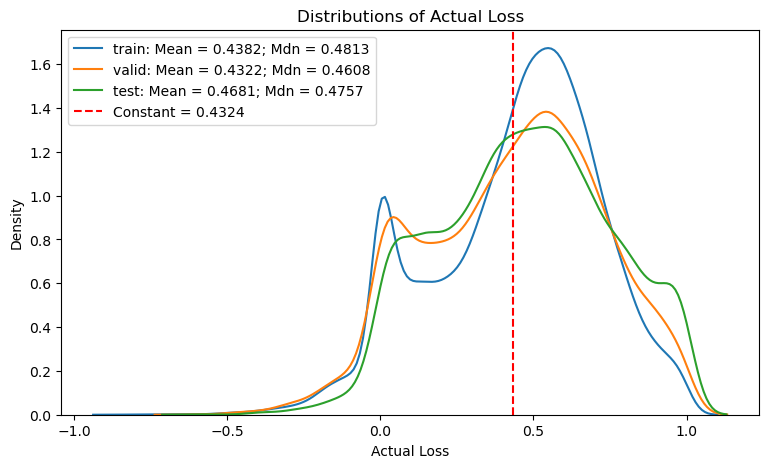

In [7]:
list_str_df = [
    'train',
    'valid',
    'test',
]
fig, ax = plt.subplots(figsize=(9,5))
str_title = 'Distributions of Actual Loss'
ax.set_title(str_title)
ax.set_xlabel('Actual Loss')
for str_df in tqdm(list_str_df):
    # subset
    df_tmp = df[df['data_set'] == str_df].copy()
    # list
    list_values = list(df_tmp['target'])
    # mean
    flt_mean = np.mean(list_values)
    # mdn
    flt_mdn = np.median(list_values)
    # label
    str_label = f'{str_df}: Mean = {flt_mean:0.4f}; Mdn = {flt_mdn:0.4f}'
    sns.kdeplot(list_values, ax=ax, label=str_label)
# line of constant
ax.axvline(flt_constant, linestyle='--', color='red', label=f'Constant = {flt_constant:0.4f}')
# legend
plt.legend()
# show
plt.show()

### Get LGD predictions

In [8]:
# get gen 12 LGD model
str_filename = 'final_model.pkl'
str_bucket_path = f'03_pricing_lgd/02_model/{str_variant}/03_final_model/{str_filename}'
str_local_path = f'{str_dirname_output}/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
cls_model_inference = pickle.load(open(str_local_path, 'rb'))['model_inference']
os.remove(str_local_path)
# predict
list_cols_model = list(cls_model_inference.feature_names_)
df['yhat'] = cls_model_inference.predict(df[list_cols_model])
# show
df

,linkf189__tu,linkf060__tu,linkf045__tu,linkb012__tu,intservicecontractmileage__app,intservicecontractterm__app,linkf185__tu,linkf105__tu,linkf193__tu,linkf195__tu,...,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age,target,yhat
8202,40.0,0.0,0.0,0.0,0.0,24.0,152.0,40.0,40.0,1141.0,...,2013,1.256262,10,4,0.09,1.370370,4.0,1.284932,-0.097929,0.435195
8203,40.0,0.0,0.0,0.0,0.0,24.0,152.0,40.0,40.0,1141.0,...,2013,1.256262,10,4,0.09,1.370370,4.0,1.284932,-0.097929,0.419317
8204,0.0,0.0,0.0,0.0,100000.0,48.0,0.0,0.0,0.0,0.0,...,2013,1.256262,10,4,0.15,1.586207,2.0,1.569863,0.464463,0.363815
8205,0.0,0.0,0.0,0.0,100000.0,48.0,0.0,0.0,0.0,0.0,...,2013,1.256262,10,4,0.15,1.586207,2.0,1.569863,0.464463,0.346931
8206,769.0,0.0,0.0,0.0,120000.0,0.0,5.0,5.0,5.0,1802.0,...,2013,1.256262,10,4,0.03,1.342857,1.0,3.961644,0.543609,0.485704
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,1540.0,0.0,0.0,0.0,120000.0,0.0,658.0,658.0,658.0,1601.0,...,2019,1.144717,10,4,0.09,1.236842,1.0,2.953425,0.175335,0.454106
2335,48.0,0.0,0.0,0.0,120000.0,0.0,244.0,48.0,48.0,1358.0,...,2019,1.144717,10,4,0.12,1.500000,3.0,16.306849,0.317968,0.489100
5274,1493.0,0.0,0.0,0.0,120000.0,0.0,1488.0,1488.0,1488.0,1493.0,...,2019,1.144717,10,4,0.09,1.290323,3.0,6.126027,0.278606,0.452178
6464,0.0,0.0,0.0,0.0,0.0,24.0,0.0,0.0,0.0,0.0,...,2019,1.144717,10,4,0.09,1.233333,3.0,8.956164,0.660134,0.463597


### Plot distributions of predictions

100%|██████████| 3/3 [00:01<00:00,  1.97it/s]


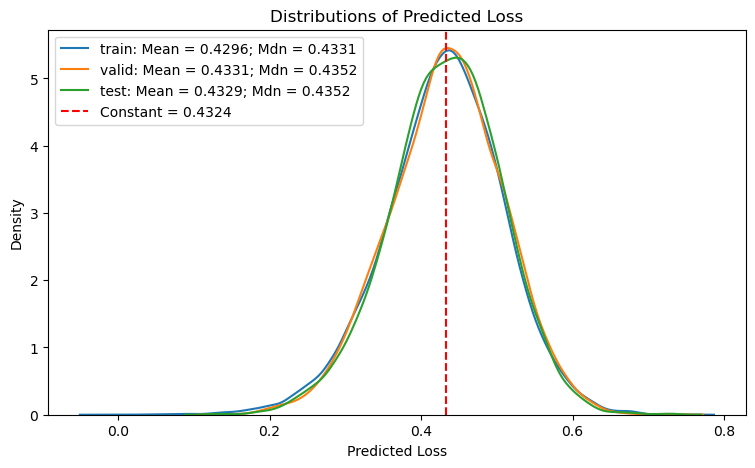

In [9]:
list_str_df = [
    'train',
    'valid',
    'test',
]
fig, ax = plt.subplots(figsize=(9,5))
str_title = 'Distributions of Predicted Loss'
ax.set_title(str_title)
ax.set_xlabel('Predicted Loss')
for str_df in tqdm(list_str_df):
    # subset
    df_tmp = df[df['data_set'] == str_df].copy()
    # list
    list_values = list(df_tmp['yhat'])
    # mean
    flt_mean = np.mean(list_values)
    # mdn
    flt_mdn = np.median(list_values)
    # label
    str_label = f'{str_df}: Mean = {flt_mean:0.4f}; Mdn = {flt_mdn:0.4f}'
    sns.kdeplot(list_values, ax=ax, label=str_label)
# line of constant
ax.axvline(flt_constant, linestyle='--', color='red', label=f'Constant = {flt_constant:0.4f}')
# legend
plt.legend()
# show
plt.show()

### Get residuals (predicted - actual)

In [10]:
df['residuals'] = df['yhat'] - df['target']

### Plot residuals (predicted - actual)

100%|██████████| 3/3 [00:01<00:00,  1.94it/s]


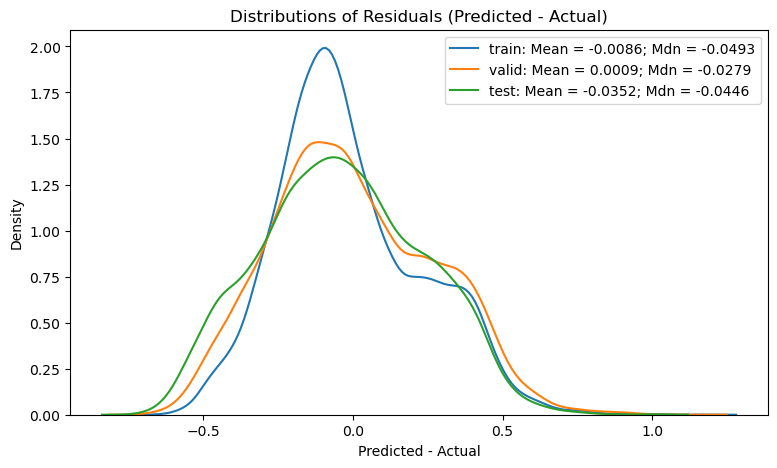

In [11]:
list_str_df = [
    'train',
    'valid',
    'test',
]
fig, ax = plt.subplots(figsize=(9,5))
str_title = 'Distributions of Residuals (Predicted - Actual)'
ax.set_title(str_title)
ax.set_xlabel('Predicted - Actual')
for str_df in tqdm(list_str_df):
    # subset
    df_tmp = df[df['data_set'] == str_df].copy()
    # list
    list_values = list(df_tmp['residuals'])
    # mean
    flt_mean = np.mean(list_values)
    # mdn
    flt_mdn = np.median(list_values)
    # label
    str_label = f'{str_df}: Mean = {flt_mean:0.4f}; Mdn = {flt_mdn:0.4f}'
    sns.kdeplot(list_values, ax=ax, label=str_label)
# legend
plt.legend()
# show
plt.show()

### Get residuals (constant - actual)

In [12]:
df['residuals'] = flt_constant - df['target']

### Plot residuals (constant - actual)

100%|██████████| 3/3 [00:01<00:00,  2.09it/s]


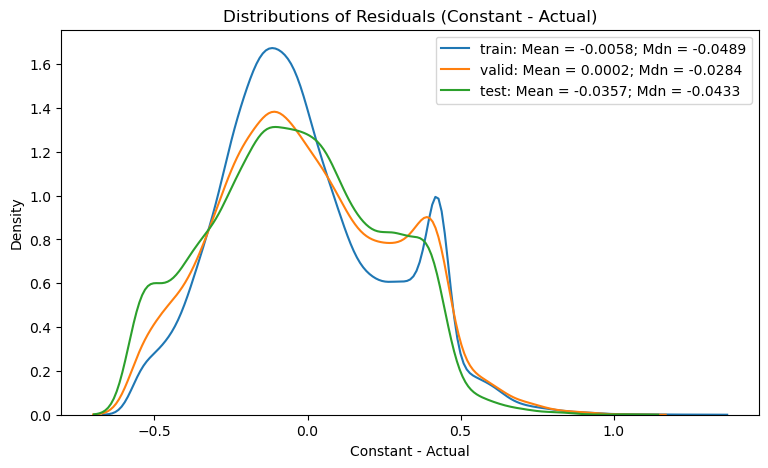

In [13]:
list_str_df = [
    'train',
    'valid',
    'test',
]
fig, ax = plt.subplots(figsize=(9,5))
str_title = 'Distributions of Residuals (Constant - Actual)'
ax.set_title(str_title)
ax.set_xlabel('Constant - Actual')
for str_df in tqdm(list_str_df):
    # subset
    df_tmp = df[df['data_set'] == str_df].copy()
    # list
    list_values = list(df_tmp['residuals'])
    # mean
    flt_mean = np.mean(list_values)
    # mdn
    flt_mdn = np.median(list_values)
    # label
    str_label = f'{str_df}: Mean = {flt_mean:0.4f}; Mdn = {flt_mdn:0.4f}'
    sns.kdeplot(list_values, ax=ax, label=str_label)
# legend
plt.legend()
# show
plt.show()

### Get RMSE by data set for model

In [14]:
list_str_df = [
    'train',
    'valid',
    'test',
]
list_dict_row = []
for str_df in tqdm(list_str_df):
    # subset
    df_tmp = df[df['data_set'] == str_df].copy()
    # get rmse
    flt_score = np.sqrt(skm.mean_squared_error(
        y_true=df_tmp['target'], 
        y_pred=df_tmp['yhat'],
    ))
    dict_row = {
        'df': str_df,
        'score': flt_score,
    }
    list_dict_row.append(dict_row)
df_model_score = pd.DataFrame(list_dict_row)
df_model_score

100%|██████████| 3/3 [00:01<00:00,  2.83it/s]


,df,score
0,train,0.242545
1,valid,0.271581
2,test,0.272653


### Look at the vinatage level

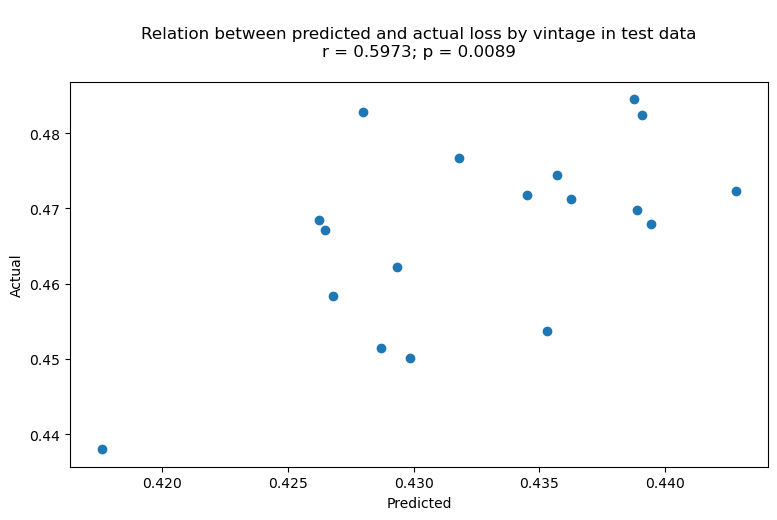

In [15]:
str_data_set = 'test'
df_tmp = df[df['data_set'] == str_data_set].copy()
df_tmp['app_month'] = df_tmp['applicationdate__app'].dt.to_period('M').dt.to_timestamp()
df_tmp = df_tmp.groupby(by='app_month', as_index=False).agg({
    'yhat': 'mean',
    'target': 'mean'
})
flt_coef, flt_p = pearsonr(df_tmp['yhat'], df_tmp['target'])
str_title =  f"""
Relation between predicted and actual loss by vintage in {str_data_set} data
r = {flt_coef:0.4f}; p = {flt_p:0.4f}
"""
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.scatter(df_tmp['yhat'], df_tmp['target'])
plt.show()

### Get RMSE by data set using constant

In [16]:
list_str_df = [
    'train',
    'valid',
    'test',
]
list_dict_row = []
for str_df in tqdm(list_str_df):
    # subset
    df_tmp = df[df['data_set'] == str_df].copy()
    df_tmp['constant'] = flt_constant
    # get rmse
    flt_score = np.sqrt(skm.mean_squared_error(
        y_true=df_tmp['target'], 
        y_pred=df_tmp['constant'],
    ))
    dict_row = {
        'df': str_df,
        'score': flt_score,
    }
    list_dict_row.append(dict_row)
df_constant_score = pd.DataFrame(list_dict_row)
df_constant_score

100%|██████████| 3/3 [00:01<00:00,  2.74it/s]


,df,score
0,train,0.272923
1,valid,0.286942
2,test,0.283003


### Join

In [17]:
df_model_score.columns = ['df', 'score_model']
df_constant_score.columns = ['df', 'score_constant']
df_scores = pd.merge(
    left=df_model_score,
    right=df_constant_score,
    on='df',
    how='inner',
)
df_scores

,df,score_model,score_constant
0,train,0.242545,0.272923
1,valid,0.271581,0.286942
2,test,0.272653,0.283003


### Plot actuals with predictions and constant for each data set

In [18]:
df.sort_values(by='target', ascending=True, inplace=True)
df['constant'] = flt_constant

  0%|          | 0/3 [00:00<?, ?it/s]

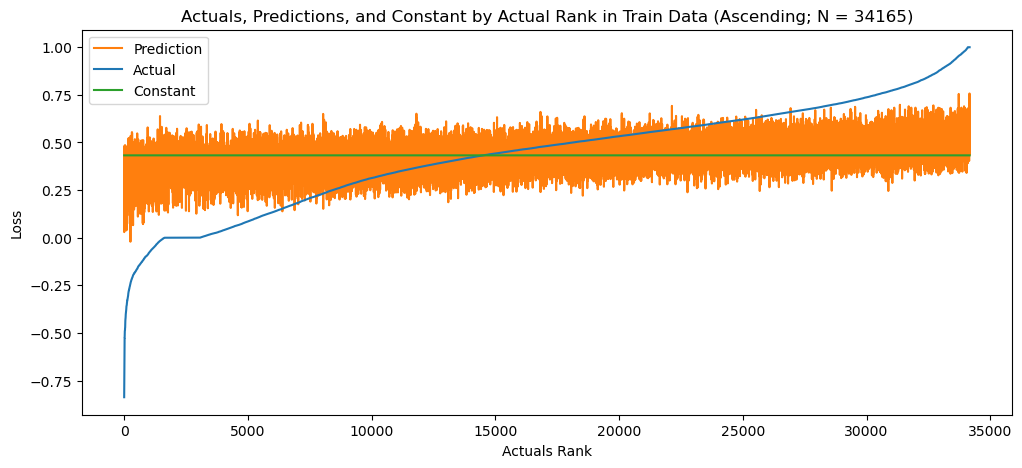

 33%|███▎      | 1/3 [00:01<00:02,  1.06s/it]

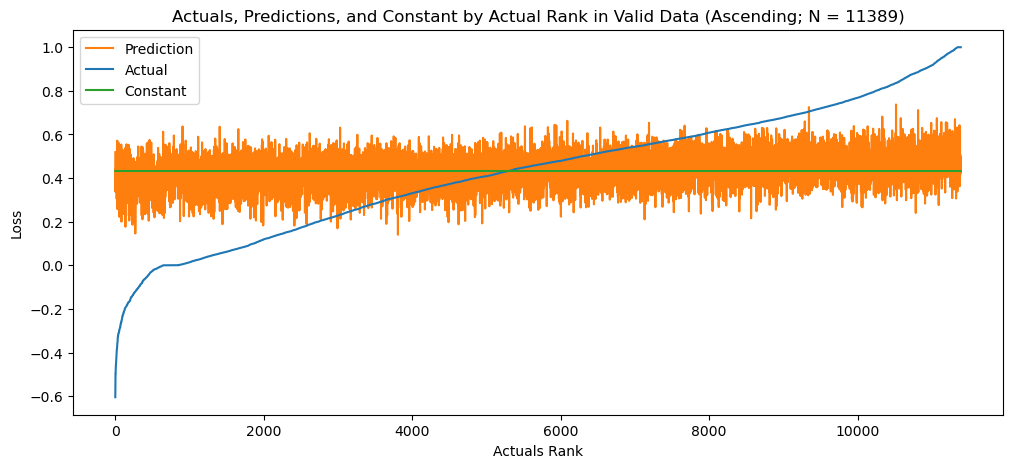

 67%|██████▋   | 2/3 [00:01<00:00,  1.35it/s]

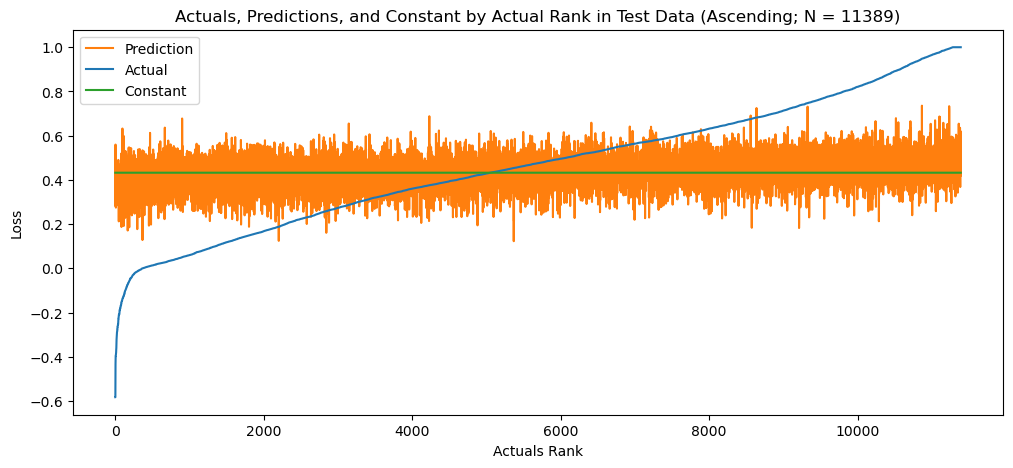

100%|██████████| 3/3 [00:02<00:00,  1.43it/s]


In [19]:
list_str_df = [
    'train',
    'valid',
    'test',
]
for str_df in tqdm(list_str_df):
    # subset
    df_tmp = df[df['data_set'] == str_df].copy()
    # rank
    df_tmp['target_rank'] = list(range(0, df_tmp.shape[0]))
    # plot
    fig, ax = plt.subplots(figsize=(12,5))
    str_title = f'Actuals, Predictions, and Constant by Actual Rank in {str_df.capitalize()} Data (Ascending; N = {df_tmp.shape[0]})'
    ax.set_title(str_title)
    ax.set_xlabel('Actuals Rank')
    ax.set_ylabel('Loss')
    # predictions
    ax.plot(df_tmp['target_rank'], df_tmp['yhat'], label='Prediction', color='tab:orange')
    # actual
    ax.plot(df_tmp['target_rank'], df_tmp['target'], label='Actual', color='tab:blue')
    # constant
    ax.plot(df_tmp['target_rank'], df_tmp['constant'], label='Constant', color='tab:green')
    # legend
    plt.legend()
    # show
    plt.show()

### Show LTV

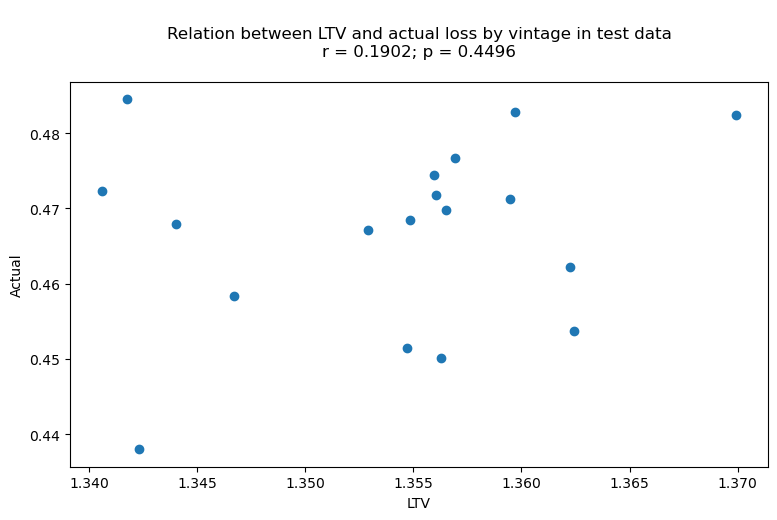

In [20]:
str_data_set = 'test'
df_tmp = df[df['data_set'] == str_data_set].copy()
df_tmp['app_month'] = df_tmp['applicationdate__app'].dt.to_period('M').dt.to_timestamp()
df_tmp = df_tmp.groupby(by='app_month', as_index=False).agg({
    'yhat': 'mean',
    'target': 'mean',
    'ENG-loan_to_value': 'mean',
})
flt_coef, flt_p = pearsonr(df_tmp['ENG-loan_to_value'], df_tmp['target'])
str_title =  f"""
Relation between LTV and actual loss by vintage in {str_data_set} data
r = {flt_coef:0.4f}; p = {flt_p:0.4f}
"""
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('LTV')
ax.set_ylabel('Actual')
ax.scatter(df_tmp['ENG-loan_to_value'], df_tmp['target'])
plt.show()

100%|██████████| 3/3 [00:01<00:00,  1.78it/s]


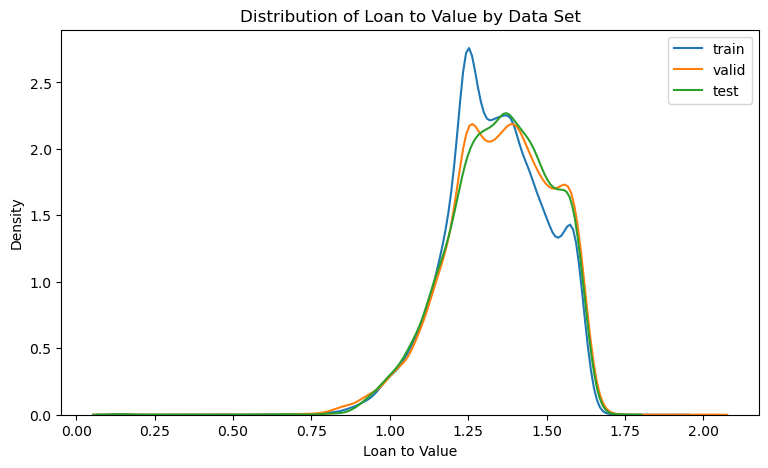

In [21]:
fig, ax = plt.subplots(figsize=(9,5))
str_title = 'Distribution of Loan to Value by Data Set'
ax.set_title(str_title)
ax.set_xlabel('Loan to Value')
list_str_df = [
    'train',
    'valid',
    'test',
]
for str_df in tqdm(list_str_df):
    # subset
    df_tmp = df[df['data_set'] == str_df].copy()
    sns.kdeplot(list(df_tmp['ENG-loan_to_value']), label=str_df)
# legend
plt.legend()
# show
plt.show()

  0%|          | 0/3 [00:00<?, ?it/s]

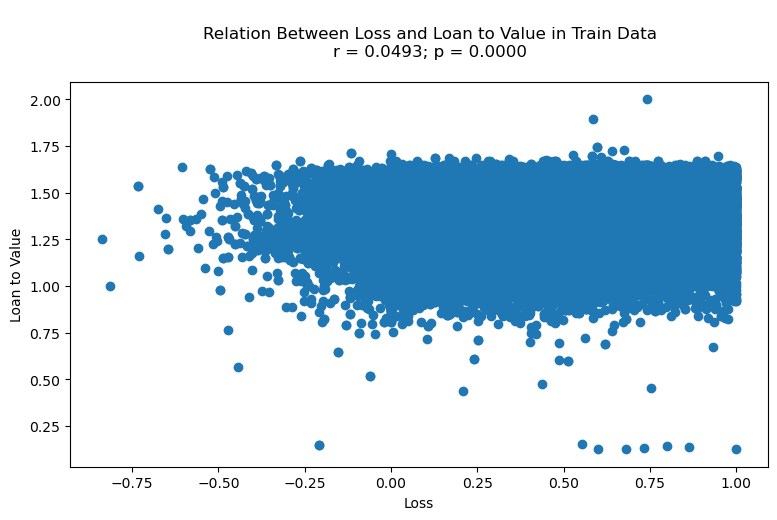

 33%|███▎      | 1/3 [00:00<00:01,  1.05it/s]

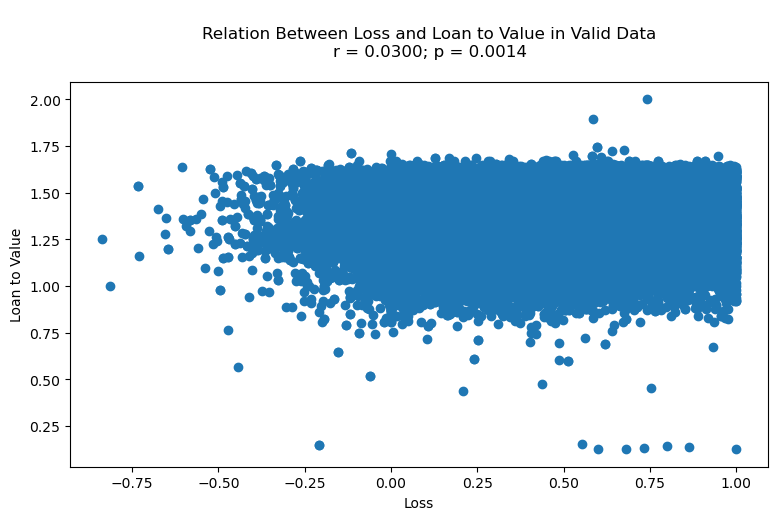

 67%|██████▋   | 2/3 [00:01<00:00,  1.41it/s]

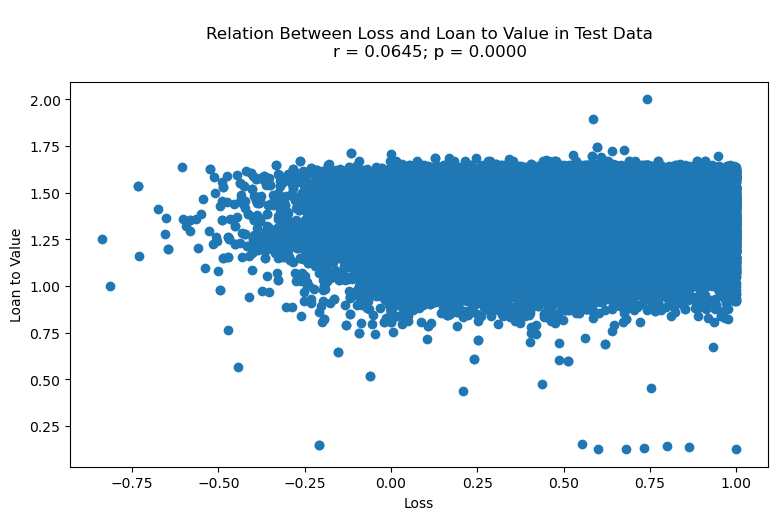

100%|██████████| 3/3 [00:02<00:00,  1.47it/s]


In [22]:
# relationship of LTV to loss
list_str_df = [
    'train',
    'valid',
    'test',
]
for str_df in tqdm(list_str_df):
    # subset
    df_tmp = df[df['data_set'] == str_df].copy()
    flt_coef, flt_p = pearsonr(df_tmp['target'], df_tmp['ENG-loan_to_value'])
    fig, ax = plt.subplots(figsize=(9,5))
    str_title = f"""
    Relation Between Loss and Loan to Value in {str_df.capitalize()} Data
    r = {flt_coef:0.4f}; p = {flt_p:0.4f}
    """
    ax.set_title(str_title)
    ax.set_xlabel('Loss')
    ax.set_ylabel('Loan to Value')
    plt.scatter(df['target'], df['ENG-loan_to_value'])
    plt.show()

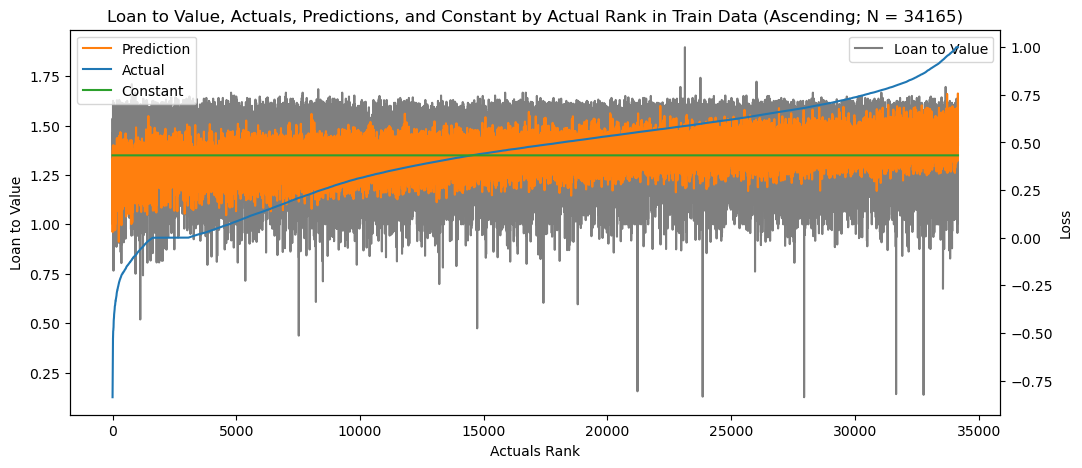

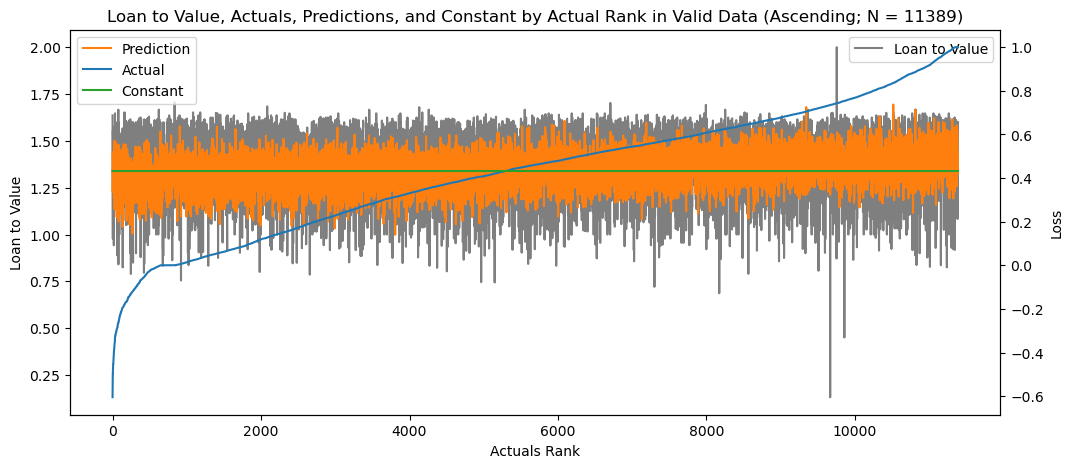

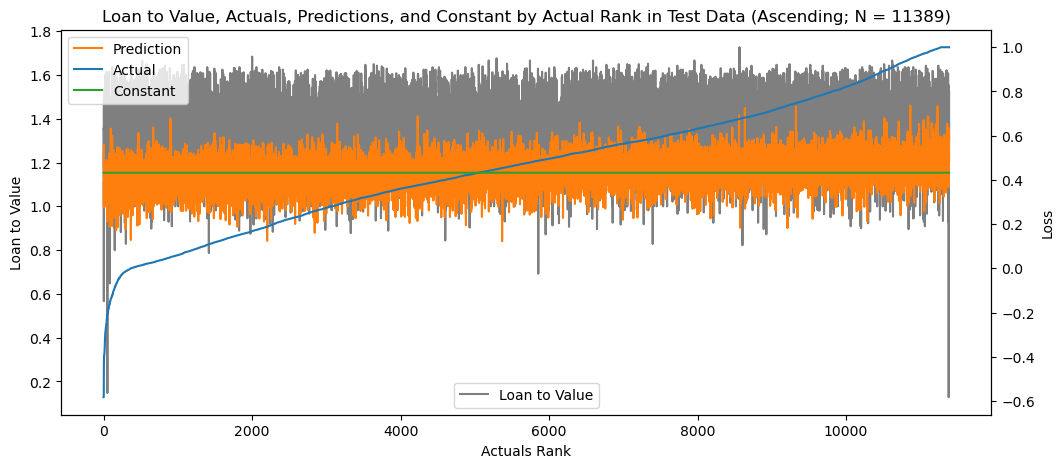

In [23]:
list_str_df = [
    'train',
    'valid',
    'test',
]
for str_df in list_str_df:
    # subset
    df_tmp = df[df['data_set'] == str_df].copy()
    # rank
    df_tmp['target_rank'] = list(range(0, df_tmp.shape[0]))
    # plot
    fig, ax = plt.subplots(figsize=(12,5))
    str_title = f'Loan to Value, Actuals, Predictions, and Constant by Actual Rank in {str_df.capitalize()} Data (Ascending; N = {df_tmp.shape[0]})'
    ax.set_title(str_title)
    ax.set_xlabel('Actuals Rank')
    ax.set_ylabel('Loan to Value')
    # loan to value
    ax.plot(df_tmp['target_rank'], df_tmp['ENG-loan_to_value'], label='Loan to Value', color='tab:grey')
    # legend
    plt.legend()
    # second y axis
    ax2 = ax.twinx()
    ax2.set_ylabel('Loss')
    # predictions
    ax2.plot(df_tmp['target_rank'], df_tmp['yhat'], label='Prediction', color='tab:orange')
    # actual
    ax2.plot(df_tmp['target_rank'], df_tmp['target'], label='Actual', color='tab:blue')
    # constant
    ax2.plot(df_tmp['target_rank'], df_tmp['constant'], label='Constant', color='tab:green')
    # legend
    plt.legend()
    # show
    plt.show()